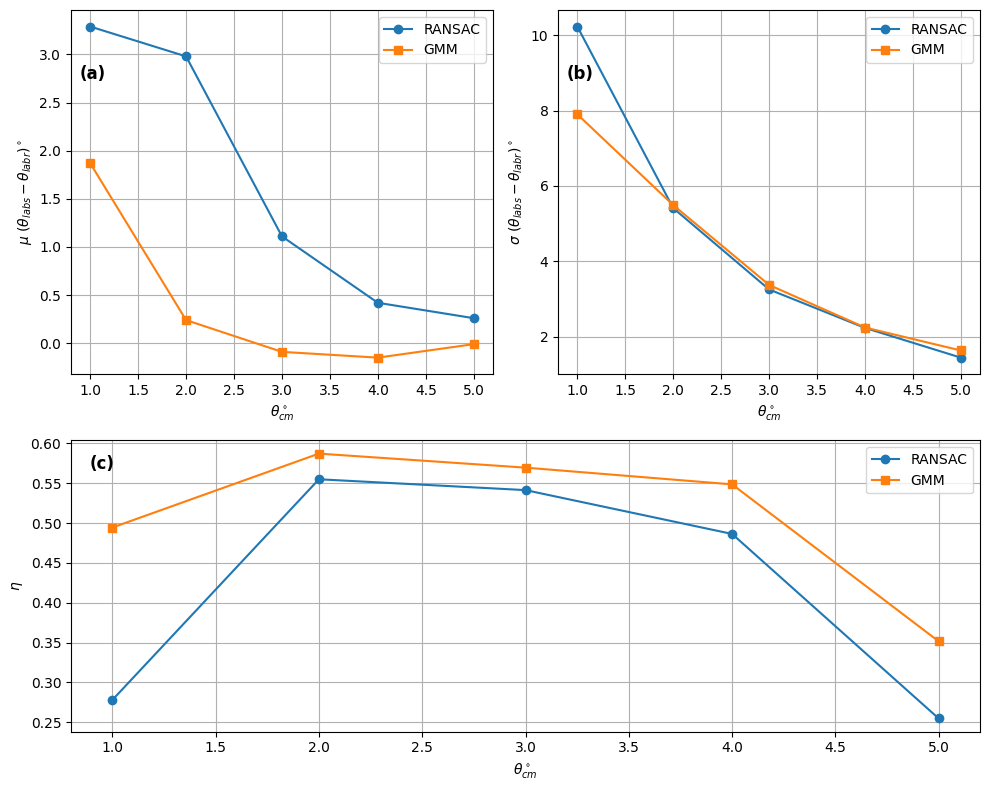

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Given data
cm_angles = np.array([1, 2, 3, 4, 5])
ransac_mean = np.array([3.29, 2.98, 1.11, 0.42, 0.26])
gmm_mean = np.array([1.87, 0.24, -0.09, -0.15, -0.01])
ransac_sigma = np.array([10.23, 5.41, 3.25, 2.23, 1.44])
gmm_sigma = np.array([7.90, 5.49, 3.37, 2.24, 1.63])
ransac_entries = np.array([1390, 2775, 2707, 2432, 1274])
gmm_entries = np.array([2472, 2936, 2848, 2743, 1758])

geometric = np.array([2869, 3188, 3155, 3077, 2977])

# Normalize entries
ransac_eta = ransac_entries / 5000
gmm_eta = gmm_entries / 5000

# Create figure and subplots
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.8])
ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[1, :])  # Bottom, centered

# Plot mean
ax1.plot(cm_angles, ransac_mean, marker='o', label='RANSAC')
ax1.plot(cm_angles, gmm_mean, marker='s', label='GMM')

ax1.set_xlabel(r'$\theta_{cm}^\circ$')
ax1.set_ylabel(r'$\mu\ (\theta_{labs}-\theta_{labr})^\circ$')
# ax1.set_title("Mean")
ax1.legend()
ax1.grid(True)
ax1.text(0.02, 0.85, '(a)', transform=ax1.transAxes, fontsize=12, fontweight='bold', va='top')

# Plot sigma
ax2.plot(cm_angles, ransac_sigma, marker='o', label='RANSAC')
ax2.plot(cm_angles, gmm_sigma, marker='s', label='GMM')
ax2.set_xlabel(r'$\theta_{cm}^\circ$')
ax2.set_ylabel(r'$\sigma\ (\theta_{labs}-\theta_{labr})^\circ$')
# ax2.set_title("Sigma")
ax2.legend()
ax2.grid(True)
ax2.text(0.02, 0.85, '(b)', transform=ax2.transAxes, fontsize=12, fontweight='bold', va='top')

# Plot entries / 5000
ax3.plot(cm_angles, ransac_eta, marker='o', label='RANSAC')
ax3.plot(cm_angles, gmm_eta, marker='s', label='GMM')
ax3.set_xlabel(r'$\theta_{cm}^\circ$')
ax3.set_ylabel(r'$\eta$')
# ax3.set_title("Entries / 5000")
ax3.legend()
ax3.grid(True)
ax3.text(0.02, 0.95, '(c)', transform=ax3.transAxes, fontsize=12, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('compare.png', dpi=300, bbox_inches='tight')
plt.show()



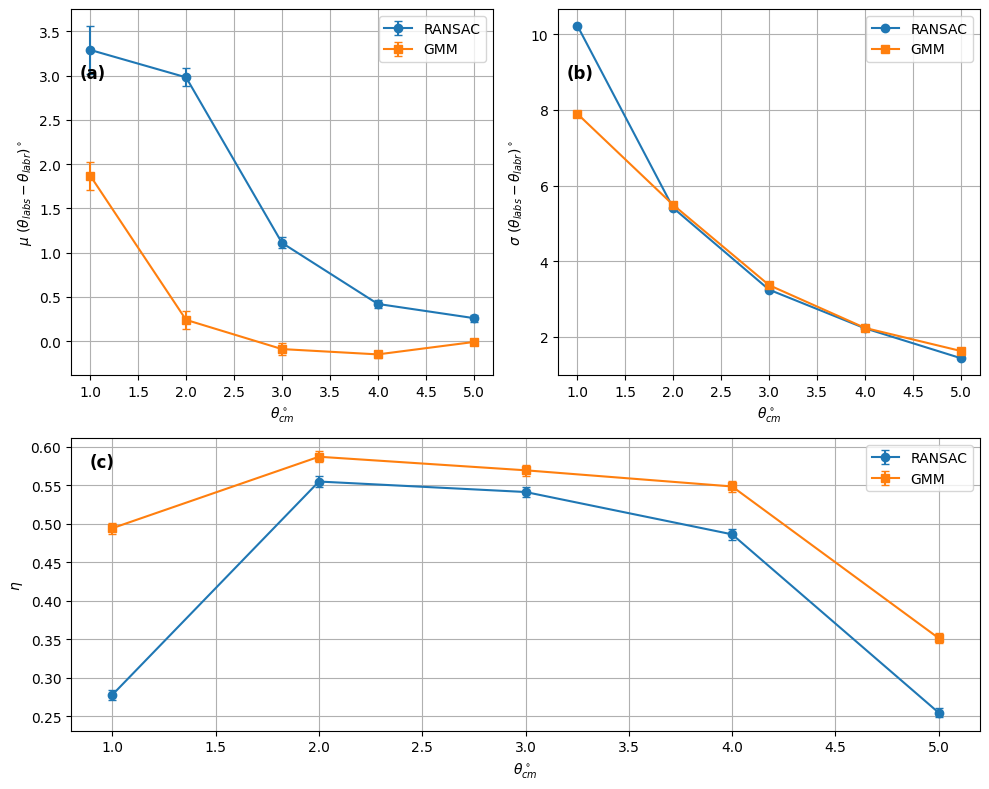

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Given data
cm_angles = np.array([1, 2, 3, 4, 5])
ransac_mean = np.array([3.29, 2.98, 1.11, 0.42, 0.26])
gmm_mean = np.array([1.87, 0.24, -0.09, -0.15, -0.01])
ransac_sigma = np.array([10.23, 5.41, 3.25, 2.23, 1.44])
gmm_sigma = np.array([7.90, 5.49, 3.37, 2.24, 1.63])
ransac_entries = np.array([1390, 2775, 2707, 2432, 1274])
gmm_entries = np.array([2472, 2936, 2848, 2743, 1758])
N_total = 5000

# Compute error bars
ransac_sem = ransac_sigma / np.sqrt(ransac_entries)  # SEM for mean
gmm_sem = gmm_sigma / np.sqrt(gmm_entries)

ransac_eta = ransac_entries / N_total
gmm_eta = gmm_entries / N_total
# Binomial error for efficiency
ransac_eta_err = np.sqrt(ransac_eta * (1 - ransac_eta) / N_total)
gmm_eta_err = np.sqrt(gmm_eta * (1 - gmm_eta) / N_total)

# Create figure and subplots
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.8])
ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[1, :])  # Bottom, centered

# Plot mean with error bars
ax1.errorbar(cm_angles, ransac_mean, yerr=ransac_sem, marker='o', label='RANSAC', capsize=3)
ax1.errorbar(cm_angles, gmm_mean, yerr=gmm_sem, marker='s', label='GMM', capsize=3)
ax1.set_xlabel(r'$\theta_{cm}^\circ$')
ax1.set_ylabel(r'$\mu\ (\theta_{labs}-\theta_{labr})^\circ$')
ax1.legend()
ax1.grid(True)
ax1.text(0.02, 0.85, '(a)', transform=ax1.transAxes, fontsize=12, fontweight='bold', va='top')

# Plot sigma (no error bars)
ax2.plot(cm_angles, ransac_sigma, marker='o', label='RANSAC')
ax2.plot(cm_angles, gmm_sigma, marker='s', label='GMM')
ax2.set_xlabel(r'$\theta_{cm}^\circ$')
ax2.set_ylabel(r'$\sigma\ (\theta_{labs}-\theta_{labr})^\circ$')
ax2.legend()
ax2.grid(True)
ax2.text(0.02, 0.85, '(b)', transform=ax2.transAxes, fontsize=12, fontweight='bold', va='top')

# Plot efficiency with error bars
ax3.errorbar(cm_angles, ransac_eta, yerr=ransac_eta_err, marker='o', label='RANSAC', capsize=3)
ax3.errorbar(cm_angles, gmm_eta, yerr=gmm_eta_err, marker='s', label='GMM', capsize=3)
ax3.set_xlabel(r'$\theta_{cm}^\circ$')
ax3.set_ylabel(r'$\eta$')
ax3.legend()
ax3.grid(True)
ax3.text(0.02, 0.95, '(c)', transform=ax3.transAxes, fontsize=12, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('compare_with_errorbars.png', dpi=300, bbox_inches='tight')
plt.show()
